#**Machine Learning-Based Revenue Forecasting** and Onboarding Patterns Across Multi-Country Payment Networks: **A Case Study of Arab Financial Services**

#**Oman ABO (Arab Bank Oman) Forcast Revenue**

#SECTION 1: Setup: Google Drive + Libraries

In [1]:
# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Core libraries ---
import pandas as pd
import numpy as np

# --- Feature Engineering ---
!pip install holidays -q
import holidays
!pip install hijridate -q
from hijridate import Gregorian

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
!pip install plotly -q
import plotly.graph_objects as go

# --- Modelling ---
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
!pip install lightgbm catboost pmdarima -q
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# --- Display settings ---
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

# --- File path ---
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/Thesis/Thesis_Datasets/OM_ABO_daily_revenue_dataset.xlsx'

print('Setup complete.')
print('Libraries loaded: pandas, numpy, matplotlib, seaborn, sklearn, xgboost')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 51.5 MB/s eta 0:00:00
Setup complete.
Libraries loaded: pandas, numpy, matplotlib, seaborn, sklearn, xgboost


#SECTION 2: Data Structure

In [2]:
df_raw = pd.read_excel(FILE_PATH)
df_raw['Settlement Date'] = pd.to_datetime(df_raw['Settlement Date'])

# ---------- 2.1 Structure ----------
print('=' * 70)
print('2.1  DATA STRUCTURE')
print('=' * 70)
print(f'Shape       : {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns')
print(f'Date range  : {df_raw["Settlement Date"].min().date()}  ->  {df_raw["Settlement Date"].max().date()}')
print(f'Memory      : {df_raw.memory_usage(deep=True).sum()/1024:.1f} KB')
print()
print(df_raw.dtypes.to_frame('dtype').to_string())
print()
display(df_raw.head())

# ---------- 2.2 Data quality: nulls, duplicates, zeros ----------
print('=' * 70)
print('2.2  DATA QUALITY')
print('=' * 70)

quality = pd.DataFrame({
    'dtype'  : df_raw.dtypes.astype(str),
    'nulls'  : df_raw.isna().sum(),
    'null_%' : (df_raw.isna().sum() / len(df_raw) * 100).round(2),
    'zeros'  : (df_raw == 0).sum(),
    'unique' : df_raw.nunique(),
})
display(quality)

print(f'Duplicate full rows       : {df_raw.duplicated().sum()}')
print(f'Duplicate Settlement Dates: {df_raw["Settlement Date"].duplicated().sum()}')

full_range   = pd.date_range(df_raw['Settlement Date'].min(),
                             df_raw['Settlement Date'].max(), freq='D')
missing_days = full_range.difference(df_raw['Settlement Date'])
print(f'Missing calendar days     : {len(missing_days)}')
if 0 < len(missing_days) <= 10:
    print(f'   -> {list(missing_days.date)}')
print()

# ---------- 2.3 Statistical summary ----------
print('=' * 70)
print('2.3  STATISTICAL SUMMARY')
print('=' * 70)
num_cols = ['Transaction Count', 'Transaction Amount',
            'Average Transaction Amount', 'Profit']
stats = df_raw[num_cols].describe().T
stats['skew'] = df_raw[num_cols].skew()
display(stats.round(2))

# ---------- 2.4 Yearly consistency (margin check) ----------
print('=' * 70)
print('2.4  YEARLY BREAKDOWN — margin consistency check')
print('=' * 70)
yr = df_raw.groupby(df_raw['Settlement Date'].dt.year).agg(
    days             = ('Profit', 'size'),
    txn_count        = ('Transaction Count', 'sum'),
    amount           = ('Transaction Amount', 'sum'),
    profit           = ('Profit', 'sum'),
    avg_daily_profit = ('Profit', 'mean'),
)
yr['margin_%'] = (yr['profit'] / yr['amount'] * 100).round(2)
display(yr.round(0))

2.1  DATA STRUCTURE
Shape       : 1,277 rows  x  11 columns
Date range  : 2023-01-01  ->  2026-07-01
Memory      : 287.0 KB

                                     dtype
Country                             object
Source                              object
Currency                            object
Transaction Count                    int64
Transaction Amount                 float64
Average Transaction Amount         float64
Profit                             float64
Settlement Year                      int64
Settlement Month                     int64
Settlement Date             datetime64[ns]
Settlement Day                       int64



,Country,Source,Currency,Transaction Count,Transaction Amount,Average Transaction Amount,Profit,Settlement Year,Settlement Month,Settlement Date,Settlement Day
0,Oman,ABOPOSTILION,OMR,112515,"1,453,325.39",12.92,"30,633.97",2023,1,2023-01-01,6
1,Oman,ABOPOSTILION,OMR,91796,"1,181,878.75",12.88,"26,404.55",2023,1,2023-01-02,0
2,Oman,ABOPOSTILION,OMR,88324,"1,072,618.82",12.14,"20,903.01",2023,1,2023-01-03,1
3,Oman,ABOPOSTILION,OMR,98656,"1,212,433.00",12.29,"26,507.47",2023,1,2023-01-04,2
4,Oman,ABOPOSTILION,OMR,95280,"1,190,568.41",12.50,"26,377.09",2023,1,2023-01-05,3


2.2  DATA QUALITY


,dtype,nulls,null_%,zeros,unique
Country,object,0,0.00,0,1
Source,object,0,0.00,0,1
Currency,object,0,0.00,0,1
Transaction Count,int64,0,0.00,0,1274
Transaction Amount,float64,0,0.00,0,1277
Average Transaction Amount,float64,0,0.00,0,1256
Profit,float64,0,0.00,0,1277
Settlement Year,int64,0,0.00,0,4
Settlement Month,int64,0,0.00,0,12
Settlement Date,datetime64[ns],0,0.00,0,1277


Duplicate full rows       : 0
Duplicate Settlement Dates: 0
Missing calendar days     : 1
   -> [datetime.date(2023, 3, 27)]

2.3  STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max,skew
Transaction Count,"1,277.00","198,887.79","88,245.74","52,286.00","124,231.00","178,009.00","267,555.00","518,518.00",0.65
Transaction Amount,"1,277.00","1,949,653.43","786,219.70","388,561.03","1,308,618.06","1,804,302.68","2,476,058.35","6,066,037.75",0.84
Average Transaction Amount,"1,277.00",10.11,1.58,5.49,9.05,10.03,11.05,16.91,0.42
Profit,"1,277.00","42,609.07","17,301.46","8,690.79","28,588.74","39,544.33","54,743.88","135,316.23",0.86


2.4  YEARLY BREAKDOWN — margin consistency check


,days,txn_count,amount,profit,avg_daily_profit,margin_%
Settlement Date,,,,,,
2023,364,39748925,"438,993,279.00","9,598,173.00","26,369.00",2.00
2024,366,59523360,"607,026,730.00","13,255,593.00","36,217.00",2.00
2025,365,93286398,"885,691,471.00","19,388,656.00","53,120.00",2.00
2026,182,61421027,"557,995,949.00","12,169,364.00","66,865.00",2.00


#SECTION 3: Cleaning

###The dataset was cleaned by removing constant metadata columns, aggregating duplicate settlement dates if any, imputing missing calendar days using their respective monthly averages if any, and recomputing derived fields and calendar attributes to ensure a complete, gap-free daily time series

In [3]:
df = df_raw.copy()
df.columns = df.columns.str.strip()

# ---------- 3.1 Drop constant metadata columns ----------
df = df.drop(columns=['Country', 'Source', 'Currency'], errors='ignore')

# ---------- 3.2 Resolve duplicate dates (sum the additive metrics) ----------
n_dups = df['Settlement Date'].duplicated().sum()
df = (df.groupby('Settlement Date', as_index=False)
        .agg({'Transaction Count' : 'sum',
              'Transaction Amount': 'sum',
              'Profit'            : 'sum'}))

# ---------- 3.3 Fill missing calendar days with that MONTH's average ----------
df = df.sort_values('Settlement Date').reset_index(drop=True)

full_range   = pd.date_range(df['Settlement Date'].min(),
                             df['Settlement Date'].max(), freq='D')
missing_days = full_range.difference(df['Settlement Date'])

if len(missing_days) > 0:
    df['_ym']  = df['Settlement Date'].dt.to_period('M')
    month_avg  = df.groupby('_ym')[['Transaction Count',
                                    'Transaction Amount',
                                    'Profit']].mean()

    fills = []
    for d in missing_days:
        ym   = pd.Period(d, freq='M')
        vals = month_avg.loc[ym] if ym in month_avg.index else \
               df[['Transaction Count','Transaction Amount','Profit']].mean()
        fills.append({'Settlement Date'   : d,
                      'Transaction Count' : vals['Transaction Count'],
                      'Transaction Amount': vals['Transaction Amount'],
                      'Profit'            : vals['Profit']})

    df = df.drop(columns='_ym')
    df = pd.concat([df, pd.DataFrame(fills)], ignore_index=True)
    df = df.sort_values('Settlement Date').reset_index(drop=True)

# ---------- 3.4 Recompute Average Transaction Amount ----------
df['Average Transaction Amount'] = (
    df['Transaction Amount'] / df['Transaction Count']
).replace([np.inf, -np.inf], np.nan)

# ---------- 3.5 Rebuild calendar columns ----------
df['Settlement Year']  = df['Settlement Date'].dt.year
df['Settlement Month'] = df['Settlement Date'].dt.month
df['Settlement Day']   = df['Settlement Date'].dt.dayofweek   # 0=Mon ... 6=Sun

# ---------- 3.6 Verification ----------
final_range   = pd.date_range(df['Settlement Date'].min(),
                              df['Settlement Date'].max(), freq='D')
still_missing = final_range.difference(df['Settlement Date'])

print('=' * 70)
print('CLEANING VERIFICATION')
print('=' * 70)
print(f'Rows            : {len(df_raw):,}  ->  {len(df):,}')
print(f'Duplicate dates : {n_dups}  ->  {df["Settlement Date"].duplicated().sum()}')
print(f'Missing days    : {len(missing_days)}  ->  {len(still_missing)} ')
if len(missing_days):
    print(f'   filled       : {list(missing_days.date)}')
print()
print(f'Avg Txn Amount  : min {df["Average Transaction Amount"].min():.2f}  '
      f'max {df["Average Transaction Amount"].max():.2f}  '
      f'median {df["Average Transaction Amount"].median():.2f}')
print(f'Columns: {list(df.columns)}')
display(df.head())

CLEANING VERIFICATION
Rows            : 1,277  ->  1,278
Duplicate dates : 0  ->  0
Missing days    : 1  ->  0 
   filled       : [datetime.date(2023, 3, 27)]

Avg Txn Amount  : min 5.49  max 16.91  median 10.03
Columns: ['Settlement Date', 'Transaction Count', 'Transaction Amount', 'Profit', 'Average Transaction Amount', 'Settlement Year', 'Settlement Month', 'Settlement Day']


,Settlement Date,Transaction Count,Transaction Amount,Profit,Average Transaction Amount,Settlement Year,Settlement Month,Settlement Day
0,2023-01-01,"112,515.00","1,453,325.39","30,633.97",12.92,2023,1,6
1,2023-01-02,"91,796.00","1,181,878.75","26,404.55",12.88,2023,1,0
2,2023-01-03,"88,324.00","1,072,618.82","20,903.01",12.14,2023,1,1
3,2023-01-04,"98,656.00","1,212,433.00","26,507.47",12.29,2023,1,2
4,2023-01-05,"95,280.00","1,190,568.41","26,377.09",12.50,2023,1,3


#SECTION 5: Feature Engineering

###Calendar-based, lag, rolling-window, and Hijri-calendar features were engineered to capture weekly, monthly, and Ramadan-related patterns in daily profit, with the Ramadan effect quantified to validate the relevance of the Islamic calendar features

In [5]:
# ---------- 5.1 is_weekend (Oman: Friday=4, Saturday=5) ----------
df['is_weekend'] = df['Settlement Date'].dt.dayofweek.isin([4, 5]).astype(int)

# ---------- 5.2 is_holiday (Oman public holidays) ----------
om_holidays = holidays.Oman(years=[2023, 2024, 2025, 2026])
df['is_holiday'] = df['Settlement Date'].dt.date.isin(om_holidays).astype(int)
print(f'Holiday days flagged: {df["is_holiday"].sum()}')

# ---------- 5.3 Lag & rolling features ----------
df['profit_lag1']           = df['Profit'].shift(1)                        # yesterday's profit
df['avg_tran_lag1'] = df['Average Transaction Amount'].shift(1)    # yesterday's avg ticket size
df['roll7_mean']      = df['Profit'].rolling(7).mean().shift(1)      # last 7-day avg profit
df['profit_lag28']          = df['Profit'].shift(28)                       # four weeks back (monthly cycle)
df['roll7_std']      = df['Profit'].shift(1).rolling(7).std()
df['profit_lag14']      = df['Profit'].shift(14)
df['amount_lag14']      = df['Transaction Amount'].shift(14)
df['count_lag14']      = df['Transaction Count'].shift(14)
df['avg_tran_roll7_std'] = df['Average Transaction Amount'].shift(1).rolling(7).std()

# ---------- 5.4 Islamic-calendar (Hijri) features ----------
def _hijri(dt):
    h = Gregorian(dt.year, dt.month, dt.day).to_hijri()
    return pd.Series({'hijri_month': h.month, 'hijri_day': h.day})

_h = df['Settlement Date'].apply(_hijri)
df['hijri_month'] = _h['hijri_month']
df['hijri_day']   = _h['hijri_day']

df['is_ramadan']     = (df['hijri_month'] == 9).astype(int)                        # month 9 = Ramadan
df['ramadan_last10'] = ((df['hijri_month'] == 9) & (df['hijri_day'] >= 20)).astype(int)  # pre-Eid peak

print(f'Ramadan days flagged   : {df["is_ramadan"].sum()}')

# drop the raw hijri_month/day — they HURT as ordinal features (cyclical); keep only the flags
df = df.drop(columns=['hijri_month', 'hijri_day'])

# ---------- 5.5 FINAL DATASET ----------
print('=' * 70)
print('FINAL DATASET')
print('=' * 70)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
print()
print('--- First 10 rows ---')
display(df.head(10))

# ---------- 5.6 Ramadan effect check (nice for the thesis) ----------
print('\nRamadan effect on profit:')
r = df[df['is_ramadan']==1]['Profit'].mean()
n = df[df['is_ramadan']==0]['Profit'].mean()
print(f'  Ramadan    : {r:,.0f} OMR/day')
print(f'  Non-Ramadan: {n:,.0f} OMR/day')
print(f'  Effect     : {(r/n-1)*100:+.1f}%')

Holiday days flagged: 56
Ramadan days flagged   : 118
FINAL DATASET
Shape: 1,278 rows x 21 columns
Columns: ['Settlement Date', 'Transaction Count', 'Transaction Amount', 'Profit', 'Average Transaction Amount', 'Settlement Year', 'Settlement Month', 'Settlement Day', 'is_weekend', 'is_holiday', 'profit_lag1', 'avg_tran_lag1', 'roll7_mean', 'profit_lag28', 'roll7_std', 'profit_lag14', 'amount_lag14', 'count_lag14', 'avg_tran_roll7_std', 'is_ramadan', 'ramadan_last10']

--- First 10 rows ---


,Settlement Date,Transaction Count,Transaction Amount,Profit,Average Transaction Amount,Settlement Year,Settlement Month,Settlement Day,is_weekend,is_holiday,profit_lag1,avg_tran_lag1,roll7_mean,profit_lag28,roll7_std,profit_lag14,amount_lag14,count_lag14,avg_tran_roll7_std,is_ramadan,ramadan_last10
0,2023-01-01,"112,515.00","1,453,325.39","30,633.97",12.92,2023,1,6,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,2023-01-02,"91,796.00","1,181,878.75","26,404.55",12.88,2023,1,0,0,0,"30,633.97",12.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,2023-01-03,"88,324.00","1,072,618.82","20,903.01",12.14,2023,1,1,0,0,"26,404.55",12.88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,2023-01-04,"98,656.00","1,212,433.00","26,507.47",12.29,2023,1,2,0,0,"20,903.01",12.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,2023-01-05,"95,280.00","1,190,568.41","26,377.09",12.50,2023,1,3,0,0,"26,507.47",12.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
5,2023-01-06,"96,021.00","1,216,702.16","27,609.21",12.67,2023,1,4,1,0,"26,377.09",12.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
6,2023-01-07,"90,506.00","832,365.95","17,435.98",9.20,2023,1,5,1,0,"27,609.21",12.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
7,2023-01-08,"91,635.00","1,032,287.37","22,645.41",11.27,2023,1,6,0,0,"17,435.98",9.20,"25,124.47",NaN,"4,445.64",NaN,NaN,NaN,1.30,0,0
8,2023-01-09,"84,597.00","1,015,387.57","21,350.67",12.00,2023,1,0,0,0,"22,645.41",11.27,"23,983.25",NaN,"3,769.55",NaN,NaN,NaN,1.28,0,0
9,2023-01-10,"93,948.00","1,121,017.09","24,763.09",11.93,2023,1,1,0,0,"21,350.67",12.00,"23,261.26",NaN,"3,712.05",NaN,NaN,NaN,1.20,0,0



Ramadan effect on profit:
  Ramadan    : 45,556 OMR/day
  Non-Ramadan: 42,295 OMR/day
  Effect     : +7.7%


#SECTION 6: Train/Test Split and Evaluation Setup

###The dataset was split chronologically at 1 January 2026, with all prior data used for training and the subsequent period held out as a test set, and an evaluation function was defined to compute MAPE, MAE, and RMSE for model assessmen

In [6]:
FEATURES = ['Settlement Year', 'Settlement Month', 'Settlement Day',
            'is_weekend', 'is_holiday',
            'profit_lag1','avg_tran_lag1','roll7_mean', 'profit_lag28','is_ramadan', 'ramadan_last10']
TARGET = 'Profit'
SPLIT  = '2026-01-01'

def evaluate(y, p):
    ape = np.abs((y - p) / y) * 100
    return {'MAPE%' : ape.mean(),
            'MAE'   : mean_absolute_error(y, p),
            'RMSE'  : np.sqrt(mean_squared_error(y, p))
        }
# ---------- split (once — FEATURES is a single list) ----------
d  = df.dropna(subset=FEATURES + [TARGET]).copy()
tr = d[d['Settlement Date'] <  SPLIT]
te = d[d['Settlement Date'] >= SPLIT]

X_tr, y_tr = tr[FEATURES], tr[TARGET]
X_te, y_te = te[FEATURES], te[TARGET]

print(f'TRAIN: {len(tr):,} rows | {tr["Settlement Date"].min().date()} -> {tr["Settlement Date"].max().date()}')
print(f'TEST : {len(te):,} rows | {te["Settlement Date"].min().date()} -> {te["Settlement Date"].max().date()}')
print()


TRAIN: 1,068 rows | 2023-01-29 -> 2025-12-31
TEST : 182 rows | 2026-01-01 -> 2026-07-01



#SECTION 7: Model Training and Evaluation Results Comparison

###Multiple hyperparameter configurations were tested for each proposed model (Random Forest, Gradient Boosting, XGBoost) alongside a Linear Regression baseline, with the best-performing variant of each model type selected based on test set MAPE for final comparison

In [7]:
# ---------- BASELINE ----------
baselines = {
    'Linear Regression': LinearRegression(),
}

# ---------- CANDIDATE PARAMETER SETS ---------
candidates = {
   'Random Forest (A)': RandomForestRegressor(n_estimators=300, max_depth=2, random_state=42, n_jobs=-1),
    'Random Forest (B)': RandomForestRegressor(n_estimators=250, max_depth=3, random_state=42, n_jobs=-1),
    'Random Forest (C)': RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1),

    'Gradient Boosting (A)': GradientBoostingRegressor(n_estimators=300, max_depth=6, subsample=0.8, learning_rate=0.3, random_state=42),
    'Gradient Boosting (B)': GradientBoostingRegressor(n_estimators=900, max_depth=5, learning_rate=0.02, subsample=0.8, random_state=42),
    'Gradient Boosting (C)': GradientBoostingRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01, subsample=0.8, random_state=42),

    'XGBoost (A)': xgb.XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.02, random_state=42, n_jobs=-1),
    'XGBoost (B)': xgb.XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.03, subsample=0.7, random_state=42, n_jobs=-1),
    'XGBoost (C)': xgb.XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01, random_state=42, n_jobs=-1),
}

trained_models = {}
rows = []

for mname, m in baselines.items():
    m.fit(X_tr, y_tr)
    pred_te = m.predict(X_te)
    test_metrics = evaluate(y_te.values, pred_te)
    rows.append({'Type': 'Baseline', 'Model': mname,
                 'Test MAPE%': test_metrics['MAPE%'],
                 'MAE': test_metrics['MAE'], 'RMSE': test_metrics['RMSE']})
    trained_models[mname] = m

for mname, m in candidates.items():
    m.fit(X_tr, y_tr)
    pred_te = m.predict(X_te)
    test_metrics = evaluate(y_te.values, pred_te)
    rows.append({'Type': 'Candidate', 'Model': mname,
                 'Test MAPE%': test_metrics['MAPE%'],
                 'MAE': test_metrics['MAE'], 'RMSE': test_metrics['RMSE']})
    trained_models[mname] = m

results = pd.DataFrame(rows).sort_values('Test MAPE%').reset_index(drop=True)

print('Arab Bank Oman (ABO) — PARAMETER COMPARISON (2026 test set)')
display(results.round(2))

print(f"\nBest overall (any variant): {results.loc[0, 'Model']} (Test MAPE: {results.loc[0, 'Test MAPE%']:.2f}%)")

# FINAL COMPARISON — best variant of each model type (detailed)

final_rows = []

lr_row = results[results['Model'] == 'Linear Regression'].iloc[0]
final_rows.append(lr_row)

for family in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    family_rows = results[results['Model'].str.startswith(family)]
    best_variant = family_rows.loc[family_rows['Test MAPE%'].idxmin()]
    final_rows.append(best_variant)

final_results = pd.DataFrame(final_rows).reset_index(drop=True)
final_results = final_results.sort_values('Test MAPE%').reset_index(drop=True)

# --- Store the winning model of each family for later use ---
best_per_family = {}
best_per_family['Linear Regression'] = trained_models['Linear Regression']
for family in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    best_name = final_results[final_results['Model'].str.startswith(family)]['Model'].iloc[0]
    best_per_family[family] = trained_models[best_name]

# SIMPLE SUMMARY TABLE
simple_rows = []

lr_pred = trained_models['Linear Regression'].predict(X_te)
lr_metrics = evaluate(y_te.values, lr_pred)
simple_rows.append({'Type': 'Baseline', 'Model': 'Linear Regression', **lr_metrics})

for family in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    best_name = final_results[final_results['Model'].str.startswith(family)]['Model'].iloc[0]
    best_model = trained_models[best_name]
    pred = best_model.predict(X_te)
    metrics = evaluate(y_te.values, pred)
    simple_rows.append({'Type': 'Proposed', 'Model': family, **metrics})

simple_results = pd.DataFrame(simple_rows)

print('\nArab Bank Oman (ABO) MODEL COMPARISON (2026 test set)')
display(simple_results.round(2))

best_idx = simple_results['MAPE%'].idxmin()
print(f"\nBest model: {simple_results.loc[best_idx, 'Model']} (MAPE: {simple_results.loc[best_idx, 'MAPE%']:.2f}%)")

Arab Bank Oman (ABO) — PARAMETER COMPARISON (2026 test set)


,Type,Model,Test MAPE%,MAE,RMSE
0,Candidate,XGBoost (B),13.41,"9,243.13","13,512.22"
1,Candidate,XGBoost (A),13.54,"9,388.80","13,845.13"
2,Candidate,XGBoost (C),13.63,"9,443.13","13,828.54"
3,Candidate,Random Forest (C),13.88,"9,282.98","13,794.03"
4,Candidate,Gradient Boosting (B),14.19,"9,912.30","14,728.66"
5,Candidate,Gradient Boosting (C),14.38,"10,067.55","14,988.90"
6,Candidate,Gradient Boosting (A),15.63,"10,608.45","14,701.75"
7,Candidate,Random Forest (B),16.00,"10,835.45","15,546.82"
8,Baseline,Linear Regression,16.16,"9,317.17","13,383.87"
9,Candidate,Random Forest (A),18.52,"12,768.00","17,610.49"



Best overall (any variant): XGBoost (B) (Test MAPE: 13.41%)

Arab Bank Oman (ABO) MODEL COMPARISON (2026 test set)


,Type,Model,MAPE%,MAE,RMSE
0,Baseline,Linear Regression,16.16,"9,317.17","13,383.87"
1,Proposed,Random Forest,13.88,"9,282.98","13,794.03"
2,Proposed,Gradient Boosting,14.19,"9,912.30","14,728.66"
3,Proposed,XGBoost,13.41,"9,243.13","13,512.22"



Best model: XGBoost (MAPE: 13.41%)


#SECTION 8: Check Overfitting/Underfitting

#Time-Series Cross Validation

###Time-series cross-validation was performed by testing each model on the January–February period of every available year, with training data restricted to all prior periods, in order to assess overfitting

In [ ]:
# TIME-SERIES CROSS-VALIDATION — First 2 months (Jan-Feb) of each year as test
def evaluate(y, p):
    ape = np.abs((y - p) / y) * 100
    return {'MAPE%': ape.mean(),
            'MAE': mean_absolute_error(y, p),
            'RMSE': np.sqrt(mean_squared_error(y, p))}

d = df.dropna(subset=FEATURES + ['Profit']).copy()

years_present = sorted(d['Settlement Date'].dt.year.unique())
# Only years where we actually have Jan-Feb data to test on, AND prior data to train on
fold_years = [y for y in years_present if
              not d[(d['Settlement Date'].dt.year == y) & (d['Settlement Date'].dt.month <= 2)].empty
              and not d[d['Settlement Date'] < pd.Timestamp(f'{y}-01-01')].empty]

print(f'CV folds (test = Jan-Feb of each year): {fold_years}\n')

all_fold_results = []

for test_year in fold_years:
    test_start = pd.Timestamp(f'{test_year}-01-01')
    test_end = pd.Timestamp(f'{test_year}-02-28') if test_year % 4 != 0 else pd.Timestamp(f'{test_year}-02-29')

    # Train on everything BEFORE this year started (all prior years)
    train_fold = d[d['Settlement Date'] < test_start]
    test_fold = d[(d['Settlement Date'] >= test_start) & (d['Settlement Date'] <= test_end)]

    if len(train_fold) < 30 or len(test_fold) == 0:
        print(f'Skipping {test_year}: insufficient train ({len(train_fold)}) or test ({len(test_fold)}) rows')
        continue

    X_tr_fold, y_tr_fold = train_fold[FEATURES], train_fold['Profit']
    X_te_fold, y_te_fold = test_fold[FEATURES], test_fold['Profit']

    print(f'--- Fold: test = Jan-Feb {test_year} ---')
    print(f'  Train: {len(train_fold)} days ({train_fold["Settlement Date"].min().date()} to {train_fold["Settlement Date"].max().date()})')
    print(f'  Test : {len(test_fold)} days ({test_fold["Settlement Date"].min().date()} to {test_fold["Settlement Date"].max().date()})')

    for mname, model_cls in best_per_family.items():   # <-- only the BEST variant per family, not all
        # Re-instantiate fresh each fold, using the ALREADY-TUNED hyperparameters
        model_fold = type(model_cls)(**model_cls.get_params())
        model_fold.fit(X_tr_fold, y_tr_fold)

        pred_train = model_fold.predict(X_tr_fold)
        pred_test = model_fold.predict(X_te_fold)

        train_metrics = evaluate(y_tr_fold.values, pred_train)
        test_metrics = evaluate(y_te_fold.values, pred_test)

        all_fold_results.append({
            'Fold (test year)': test_year,
            'Model': mname,
            'Train MAPE%': train_metrics['MAPE%'],
            'Test MAPE%': test_metrics['MAPE%'],
            'Gap': test_metrics['MAPE%'] - train_metrics['MAPE%'],
        })
    print()

cv_results_df = pd.DataFrame(all_fold_results)
print('='*70)
print('PER-FOLD RESULTS')
print('='*70)
print(cv_results_df.round(2).to_string(index=False))

CV folds (test = Jan-Feb of each year): [np.int32(2024), np.int32(2025), np.int32(2026)]

--- Fold: test = Jan-Feb 2024 ---
  Train: 337 days (2023-01-29 to 2023-12-31)
  Test : 60 days (2024-01-01 to 2024-02-29)

--- Fold: test = Jan-Feb 2025 ---
  Train: 703 days (2023-01-29 to 2024-12-31)
  Test : 59 days (2025-01-01 to 2025-02-28)

--- Fold: test = Jan-Feb 2026 ---
  Train: 1068 days (2023-01-29 to 2025-12-31)
  Test : 59 days (2026-01-01 to 2026-02-28)

PER-FOLD RESULTS
 Fold (test year)             Model  Train MAPE%  Test MAPE%   Gap
             2024 Linear Regression        13.24       10.36 -2.88
             2024     Random Forest         4.50        9.47  4.97
             2024 Gradient Boosting         0.84       11.78 10.94
             2024           XGBoost         3.15       13.83 10.68
             2025 Linear Regression        12.80       11.61 -1.19
             2025     Random Forest         4.37       12.96  8.59
             2025 Gradient Boosting         2.15   

#Train/Test Split Check

###A single train/test split comparison was performed to check for overfitting by measuring the gap between training and testing MAPE for each model

In [ ]:
def mape(y, p):
    return np.mean(np.abs((y - p) / y)) * 100

# ---- collect train vs test scores for each model ----
names, tr_mape, te_mape, tr_rmse, te_rmse = [], [], [], [], []

for mname, model in best_per_family.items():   # <-- only the BEST variant per family
    names.append(mname)
    tr_mape.append(mape(y_tr.values, model.predict(X_tr)))
    te_mape.append(mape(y_te.values, model.predict(X_te)))
    tr_rmse.append(np.sqrt(mean_squared_error(y_tr, model.predict(X_tr))))
    te_rmse.append(np.sqrt(mean_squared_error(y_te, model.predict(X_te))))

# ---- print the gap table ----
print(f'{"Model":<20}{"Train MAPE":>11}{"Test MAPE":>11}{"Gap":>8}')
print('-' * 50)
for i in range(len(names)):
    print(f'{names[i]:<20}{tr_mape[i]:>10.2f}%{te_mape[i]:>10.2f}%{te_mape[i]-tr_mape[i]:>7.1f}')

Model                Train MAPE  Test MAPE     Gap
--------------------------------------------------
Linear Regression        12.59%     16.16%    3.6
Random Forest             4.38%     13.88%    9.5
Gradient Boosting         3.60%     14.19%   10.6
XGBoost                   6.44%     13.41%    7.0


#SECTION 9: Prediction

#End of 2026 (Day by day)

###The daily recursive forecast (July to December 2026), combined with actual historical data, was exported to an Excel file for external review and reporting

In [8]:
FEATURES = ['Settlement Year','Settlement Month','Settlement Day',
            'is_weekend','is_holiday',
            'profit_lag1','avg_tran_lag1','roll7_mean','profit_lag28',
            'is_ramadan','ramadan_last10']

# --- Explicitly select XGBoost, not the ambiguous last-loop-iteration model ---
model = best_per_family['XGBoost']
print('Using model:', type(model).__name__)

model_features = model.get_booster().feature_names
print('Model expects features in this order:', model_features)

OM = holidays.Oman(years=[2023,2024,2025,2026])

def hijri_md(dt):
    h = Gregorian(dt.year, dt.month, dt.day).to_hijri()
    return h.month, h.day

last_date    = df['Settlement Date'].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), '2026-12-31', freq='D')

profit_hist   = list(df['Profit'].values)
avg_tran_hist = list(df['Average Transaction Amount'].values)

future_rows = []
for dt in future_dates:
    hm, hd = hijri_md(dt)
    avg_tran_lag1 = np.mean(avg_tran_hist[-28:])

    feat = {
        'Settlement Year' : dt.year,
        'Settlement Month': dt.month,
        'Settlement Day'  : dt.dayofweek,
        'is_weekend'      : int(dt.dayofweek in [4, 5]),
        'is_holiday'      : int(dt.date() in OM),
        'profit_lag1'     : profit_hist[-1],
        'avg_tran_lag1'   : avg_tran_lag1,
        'roll7_mean'      : np.mean(profit_hist[-7:]),
        'profit_lag28'    : profit_hist[-28],
        'is_ramadan'      : int(hm == 9),
        'ramadan_last10'  : int(hm == 9 and hd >= 20),
    }
    yhat = float(model.predict(pd.DataFrame([feat])[model_features])[0])
    profit_hist.append(yhat)
    avg_tran_hist.append(avg_tran_lag1)

    future_rows.append({'Settlement Date': dt, 'Predicted': yhat})

future = pd.DataFrame(future_rows)

print(f'Forecast: {future["Settlement Date"].min().date()} -> {future["Settlement Date"].max().date()}')
print(f'Days forecast     : {len(future)}')
print(f'Jul-Dec 2026 total: {future["Predicted"].sum():,.0f} OMR')

# ---- combined table: actuals + forecast ----
actual = df[['Settlement Date','Profit']].rename(columns={'Profit':'Actual'})
actual['Predicted'] = np.nan
actual['Type']      = 'Actual'

fc = future.copy()
fc['Actual'] = np.nan
fc['Type']   = 'Forecast'

combined = pd.concat([actual[['Settlement Date','Actual','Predicted','Type']],
                      fc[['Settlement Date','Actual','Predicted','Type']]],
                     ignore_index=True).sort_values('Settlement Date').reset_index(drop=True)

combined['Profit_Best']       = combined['Actual'].fillna(combined['Predicted'])
combined['Cumulative Profit'] = combined.groupby(combined['Settlement Date'].dt.year)['Profit_Best'].cumsum()

combined.to_excel('OM_ABO_forecast_2026.xlsx', index=False, sheet_name='Daily Forecast')
print('\nSaved: OM_ABO_forecast_2026.xlsx')

print(f'\nFull daily forecast ({len(future)} rows):')
display(future)

Using model: XGBRegressor
Model expects features in this order: ['Settlement Year', 'Settlement Month', 'Settlement Day', 'is_weekend', 'is_holiday', 'profit_lag1', 'avg_tran_lag1', 'roll7_mean', 'profit_lag28', 'is_ramadan', 'ramadan_last10']
Forecast: 2026-07-02 -> 2026-12-31
Days forecast     : 183
Jul-Dec 2026 total: 10,935,343 OMR

Saved: OM_ABO_forecast_2026.xlsx

Full daily forecast (183 rows):


,Settlement Date,Predicted
0,2026-07-02,"68,779.91"
1,2026-07-03,"66,170.95"
2,2026-07-04,"46,346.71"
3,2026-07-05,"54,833.46"
4,2026-07-06,"61,863.05"
...,...,...
178,2026-12-27,"57,688.99"
179,2026-12-28,"62,990.88"
180,2026-12-29,"62,685.41"
181,2026-12-30,"62,410.51"


#SECTION 10: Visualization

#Monthy Forcast Line Chart

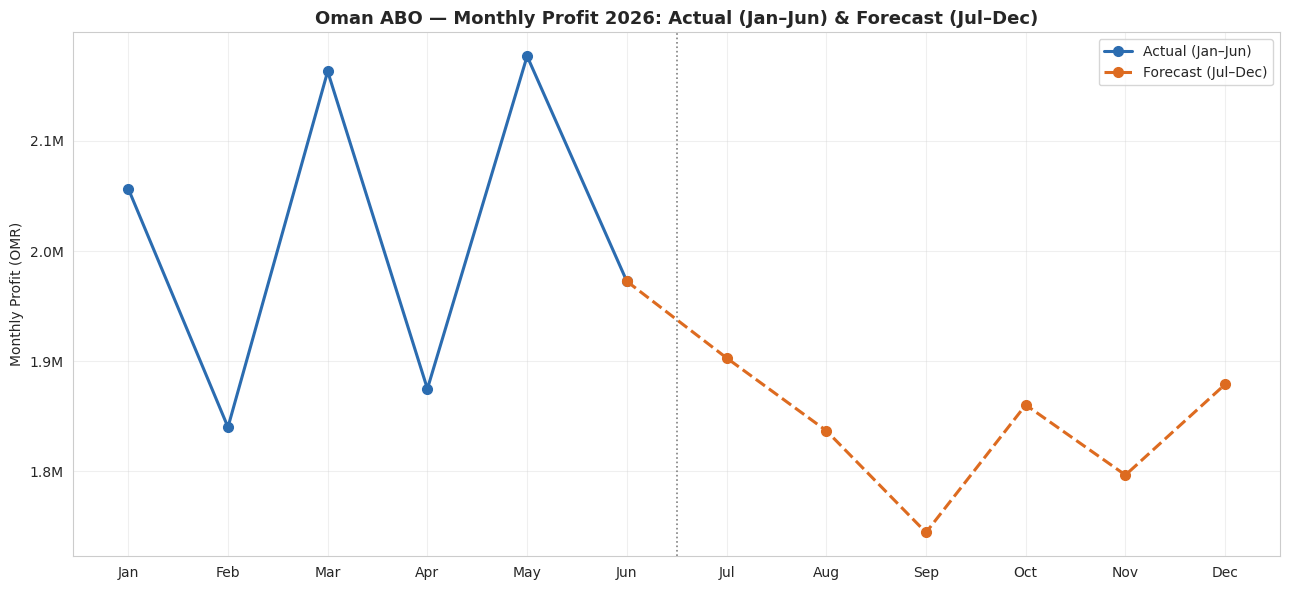

MONTHLY 2026 (OMR):
  Jan:    2,056,643  [Actual]
  Feb:    1,840,138  [Actual]
  Mar:    2,163,041  [Actual]
  Apr:    1,874,930  [Actual]
  May:    2,176,873  [Actual]
  Jun:    1,972,504  [Actual]
  Jul:    1,902,994  [Forecast]
  Aug:    1,836,968  [Forecast]
  Sep:    1,744,572  [Forecast]
  Oct:    1,860,325  [Forecast]
  Nov:    1,796,699  [Forecast]
  Dec:    1,879,019  [Forecast]

Total 2026: 23,104,707 OMR


In [9]:
# ---- combine 2026 daily actual + forecast, aggregate to MONTHLY ----
a = df[df['Settlement Date'].dt.year == 2026][['Settlement Date','Profit']].rename(columns={'Profit':'val'})
f = future.rename(columns={'Predicted':'val'})[['Settlement Date','val']]

alld = pd.concat([a, f], ignore_index=True).sort_values('Settlement Date')
alld['month'] = alld['Settlement Date'].dt.month
monthly = alld.groupby('month')['val'].sum()

names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
vals  = monthly.reindex(range(1,13)).values

# split: Jan-Jun actual, Jul-Dec forecast (overlap at Jun so the lines connect)
act_x, act_y = list(range(6)),   vals[:6]
fc_x,  fc_y  = list(range(5,12)), vals[5:]

plt.figure(figsize=(13,6))
plt.plot(act_x, act_y, 'o-',  color='#2B6CB0', lw=2.2, markersize=7, label='Actual (Jan–Jun)')
plt.plot(fc_x,  fc_y,  'o--', color='#DD6B20', lw=2.2, markersize=7, label='Forecast (Jul–Dec)')
plt.axvline(5.5, color='gray', ls=':', lw=1.2)

plt.xticks(range(12), names)
plt.ylabel('Monthly Profit (OMR)')
plt.title('Oman ABO — Monthly Profit 2026: Actual (Jan–Jun) & Forecast (Jul–Dec)',
          weight='bold', fontsize=13)
plt.legend(); plt.grid(alpha=0.3)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

# ---- print the monthly table ----
print('MONTHLY 2026 (OMR):')
for i, v in enumerate(vals):
    kind = 'Actual' if i < 6 else 'Forecast'
    print(f'  {names[i]}: {v:>12,.0f}  [{kind}]')
print(f'\nTotal 2026: {vals.sum():,.0f} OMR')

#Daily Forcast Line Chart

In [ ]:
# --- Actual daily data for all of 2026 that has happened so far ---
actual_2026 = df[df['Settlement Date'].dt.year == 2026][['Settlement Date', 'Profit']]

# --- Forecasted daily data — already runs through Dec 31, 2026 ---
forecast_2026 = future[['Settlement Date', 'Predicted']]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=actual_2026['Settlement Date'], y=actual_2026['Profit'],
    mode='lines', name='Actual',
    line=dict(color='#2B6CB0', width=1.5)
))

fig.add_trace(go.Scatter(
    x=forecast_2026['Settlement Date'], y=forecast_2026['Predicted'],
    mode='lines', name='Forecast',
    line=dict(color='#DD6B20', width=1.5, dash='dash')
))

fig.update_layout(
    title='Oman ABO — Daily Profit 2026: Actual vs Forecast (Full Year)',
    xaxis_title='Date',
    yaxis_title='Daily Profit (OMR)',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(x=0.01, y=0.99),
    width=1200, height=500,
    xaxis=dict(
        rangeslider=dict(visible=True),   # lets you drag to zoom into any period
        type='date'
    )
)
fig.update_yaxes(tickformat=',.0f')

fig.show()

# ---- print summary stats, not the full daily table (too long for full year) ----
print(f'Actual days   : {len(actual_2026)}  ({actual_2026["Settlement Date"].min().date() if len(actual_2026) else "N/A"} to {actual_2026["Settlement Date"].max().date() if len(actual_2026) else "N/A"})')
print(f'Forecast days : {len(forecast_2026)}  ({forecast_2026["Settlement Date"].min().date()} to {forecast_2026["Settlement Date"].max().date()})')
print(f'\nForecast total (remaining 2026): {forecast_2026["Predicted"].sum():,.0f} OMR')
print(f'Forecast daily mean            : {forecast_2026["Predicted"].mean():,.0f} OMR')

Actual days   : 182  (2026-01-01 to 2026-07-01)
Forecast days : 183  (2026-07-02 to 2026-12-31)

Forecast total (remaining 2026): 10,935,343 OMR
Forecast daily mean            : 59,756 OMR


#Training / Testing vs Prediction — XGBoost

###Daily and monthly visualizations were generated comparing actual training and testing data against XGBoost's predictions, with the monthly view extended through December 2026 using the recursive forecast to illustrate projected performance beyond the available data

In [10]:
SPLIT = '2026-01-01'

# --- Explicitly select XGBoost ---
model = best_per_family['XGBoost']
print('Using model:', type(model).__name__)

# --- Split and predict on the test period ---
d = df.dropna(subset=FEATURES + ['Profit'])
train = d[d['Settlement Date'] <  SPLIT]
test  = d[d['Settlement Date'] >= SPLIT].copy()

# --- Use the model's own trained feature order ---
model_features = model.get_booster().feature_names
test['Predicted'] = model.predict(test[model_features])

mape = np.mean(np.abs((test['Profit'] - test['Predicted']) / test['Profit'])) * 100
print(f'Train: {len(train)} days | Test: {len(test)} days | Test MAPE: {mape:.2f}%')

# ---------- DAILY VIEW (real data only) — interactive ----------
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=train['Settlement Date'], y=train['Profit'],
    mode='lines', name='Training data',
    line=dict(color='#1f77b4', width=0.8)
))
fig.add_trace(go.Scatter(
    x=test['Settlement Date'], y=test['Profit'],
    mode='lines', name='Testing data',
    line=dict(color='#ff7f0e', width=0.9)
))
fig.add_trace(go.Scatter(
    x=test['Settlement Date'], y=test['Predicted'],
    mode='lines', name='XGBoost (Predicted)',
    line=dict(color='#2ca02c', width=1.1)
))

fig.update_layout(
    title=dict(text='Training data / Testing data vs Predictions — Daily', font=dict(size=16)),
    xaxis_title='Date',
    yaxis_title='Profit (OMR)',
    hovermode='x unified',
    template='plotly_white',
    autosize=False,
    width=1300, height=500,
    yaxis=dict(tickformat=',.0f'),
    legend=dict(
    x=0.01, y=0.99,
    bgcolor='rgba(211,211,211,0.6)',   # light grey, semi-transparent
    bordercolor='gray',
    borderwidth=1
)
)

fig.show()

# ---------- MONTHLY VIEW — extended with recursive forecast through Dec 2026 ----------
tr_m = train.set_index('Settlement Date')['Profit'].resample('MS').sum()
te_m = test.set_index('Settlement Date')['Profit'].resample('MS').sum()
pr_m = test.set_index('Settlement Date')['Predicted'].resample('MS').sum()

# drop the final partial month of REAL test data
last_full = test['Settlement Date'].max().replace(day=1)
if test['Settlement Date'].max().day < 28:
    te_m = te_m[te_m.index < last_full]
    pr_m = pr_m[pr_m.index < last_full]

# --- Append the recursive forecast for months beyond real data ---
fc_m = future.set_index('Settlement Date')['Predicted'].resample('MS').sum()
fc_m = fc_m[fc_m.index >= last_full]

pr_m_full = pd.concat([pr_m, fc_m]).sort_index()

# --- Connect the lines visually: prepend the last training point to both lines ---
last_train_date = tr_m.index[-1]
last_train_val  = tr_m.iloc[-1]

te_m_connected = pd.concat([pd.Series({last_train_date: last_train_val}), te_m])
pr_m_full_connected = pd.concat([pd.Series({last_train_date: last_train_val}), pr_m_full])

# --- Y-axis range (same logic as before) ---
all_vals_monthly = pd.concat([tr_m, te_m_connected, pr_m_full_connected])
y_max_monthly = (int(all_vals_monthly.max() / 100000) + 2) * 100000

# ---------- MONTHLY VIEW — interactive ----------
fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=tr_m.index, y=tr_m.values, mode='lines+markers',
    name='Training data', line=dict(color='#1f77b4'), marker=dict(size=5)
))
fig2.add_trace(go.Scatter(
    x=te_m_connected.index, y=te_m_connected.values, mode='lines+markers',
    name='Testing data (actual)', line=dict(color='#ff7f0e'), marker=dict(size=6)
))
fig2.add_trace(go.Scatter(
    x=pr_m_full_connected.index, y=pr_m_full_connected.values, mode='lines+markers',
    name='XGBoost (Predicted + Forecast)', line=dict(color='#2ca02c'), marker=dict(size=6)
))

fig2.update_layout(
    title=dict(text='Training data / Testing data vs Predictions — Monthly (extended to Dec 2026)', font=dict(size=16)),
    xaxis_title='Year-Month',
    yaxis_title='Profit (OMR)',
    hovermode='x unified',
    template='plotly_white',
    width=1300, height=500,
    yaxis=dict(tickformat=',.0f', dtick=200000, range=[0, y_max_monthly]),
    legend=dict(
    x=0.01, y=0.99,
    bgcolor='rgba(211,211,211,0.6)',   # light grey, semi-transparent
    bordercolor='gray',
    borderwidth=1
)
)

fig2.show()

Using model: XGBRegressor
Train: 1068 days | Test: 182 days | Test MAPE: 13.41%


#Features Importance Bar Chart

###Feature importance scores from a comparison XGBoost model, trained on the full candidate feature set, were used to quantify the contribution of each engineered feature and justify the exclusion of low-importance transaction-based and rolling-window features from the final mode

FEATURE IMPORTANCE — full feature set (including candidate/removed features)
roll7_mean           0.41
Settlement Year      0.13
profit_lag28         0.10
profit_lag1          0.09
is_holiday           0.04
ramadan_last10       0.03
amount_lag14         0.03
Settlement Day       0.03
count_lag14          0.03
is_weekend           0.02
roll7_std            0.02
profit_lag14         0.02
is_ramadan           0.02
avg_tran_lag1        0.01
avg_tran_roll7_std   0.01
Settlement Month     0.01

Importance of REMOVED/CANDIDATE features specifically:
roll7_std            0.02
profit_lag14         0.02
amount_lag14         0.03
count_lag14          0.03
avg_tran_roll7_std   0.01

Combined importance of removed features: 0.1040
(out of total 1.0000 across all 16 features)


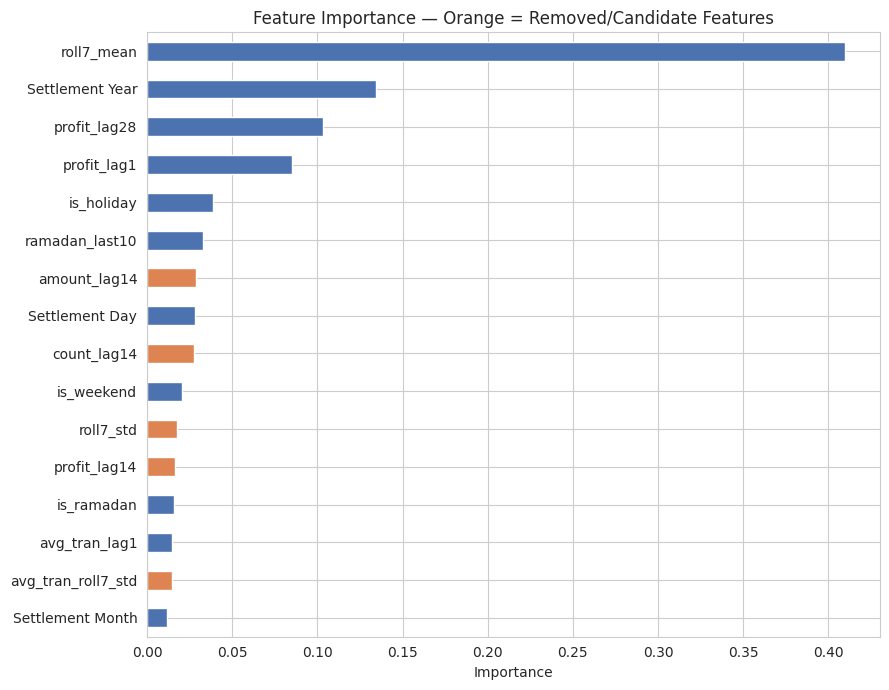

In [ ]:
FEATURES_FULL = ['Settlement Year', 'Settlement Month', 'Settlement Day',
                  'is_weekend', 'is_holiday',
                  'profit_lag1', 'avg_tran_lag1', 'roll7_mean', 'profit_lag28',
                  'is_ramadan', 'ramadan_last10',
                  'roll7_std', 'profit_lag14',
                  'amount_lag14', 'count_lag14', 'avg_tran_roll7_std']

d_full = df.dropna(subset=FEATURES_FULL + ['Profit']).copy()

X_full = d_full[FEATURES_FULL]
y_full = d_full['Profit']

# --- Train a comparison model with ALL features included ---
check_model = xgb.XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.03, subsample=0.7, random_state=42, n_jobs=-1)
check_model.fit(X_full, y_full)

importances = pd.Series(check_model.feature_importances_, index=FEATURES_FULL).sort_values(ascending=False)

print('FEATURE IMPORTANCE — full feature set (including candidate/removed features)')
print(importances.round(4).to_string())

removed_features = ['roll7_std', 'profit_lag14', 'amount_lag14', 'count_lag14', 'avg_tran_roll7_std']

print(f'\nImportance of REMOVED/CANDIDATE features specifically:')
print(importances[removed_features].round(4).to_string())
print(f'\nCombined importance of removed features: {importances[removed_features].sum():.4f}')
print(f'(out of total {importances.sum():.4f} across all {len(FEATURES_FULL)} features)')

# --- Bar chart, highlighting removed features in a different color ---
plt.figure(figsize=(9, 7))
colors = ['#DD8452' if f in removed_features else '#4C72B0' for f in importances.index]
importances.plot(kind='barh', color=colors)
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Feature Importance — Orange = Removed/Candidate Features')
plt.tight_layout()
plt.show()